In [2]:
# set up
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc

In [ ]:
# settings & figure params
sc.settings.verbosity = 1  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

/tmp/ipykernel_8332/3938469974.py:3: FutureWarning: Use `print_header` instead
  sc.logging.print_versions()
/tmp/ipykernel_8332/3938469974.py:4: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")


In [4]:
# this is an earlier version of the dataset from the classic pbmc3k tutorial
adata_ref = sc.datasets.pbmc3k_processed() # annotated dataset
adata = sc.datasets.pbmc68k_reduced() # dataset for which we want to query labels and embeddings

/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 23.5M/23.5M [00:00<00:00, 127MB/s]


In [5]:
# define on same variables
var_names = adata_ref.var_names.intersection(adata.var_names)
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

In [6]:
# PCA, neighbors, UMAP
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)


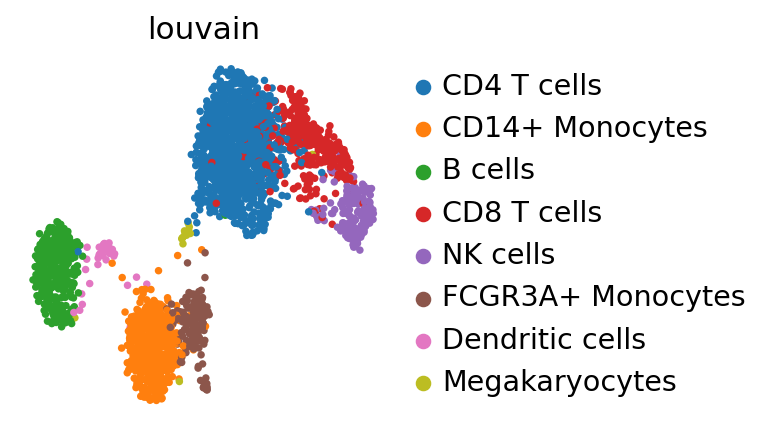

In [7]:
# manifold
sc.pl.umap(adata_ref, color="louvain")

In [8]:
# mapping PBMCs using ingest
sc.tl.ingest(adata, adata_ref, obs="louvain")

In [9]:
adata.uns["louvain_colors"] = adata_ref.uns["louvain_colors"]  # fix colors

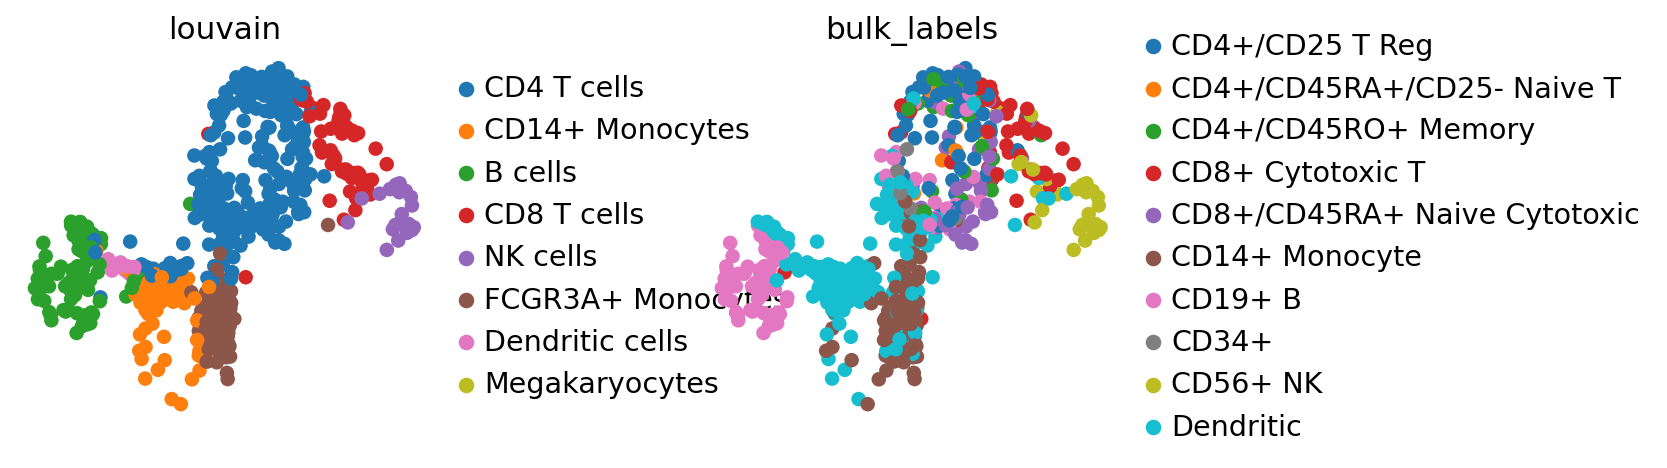

In [ ]:
# UMAP with bulk labels
sc.pl.umap(adata, color=["louvain", "bulk_labels"], wspace=0.5)

In [11]:
adata_concat = anndata.concat([adata_ref, adata], label="batch", keys=["ref", "new"])

In [12]:
adata_concat.obs["louvain"] = (
    adata_concat.obs["louvain"].astype("category").cat.reorder_categories(adata_ref.obs["louvain"].cat.categories)
)
# fix category colors
adata_concat.uns["louvain_colors"] = adata_ref.uns["louvain_colors"]

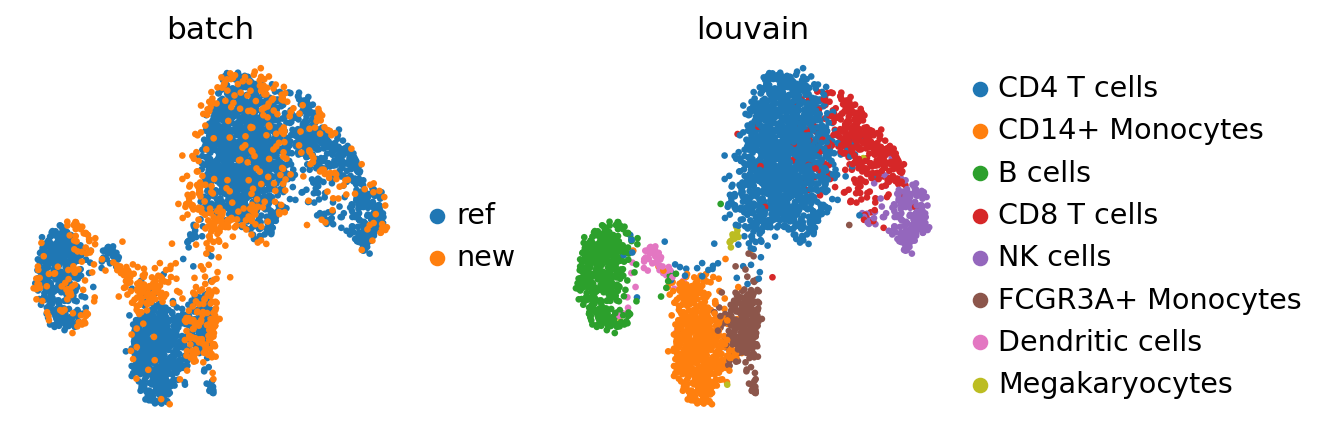

In [13]:
# batch UMAP
sc.pl.umap(adata_concat, color=["batch", "louvain"])

In [22]:
sc.tl.pca(adata_concat)

In [23]:
# BBKNN for comparison
sc.external.pp.bbknn(adata_concat, batch_key="batch")  # running bbknn 1.3.6

In [24]:
sc.tl.umap(adata_concat)

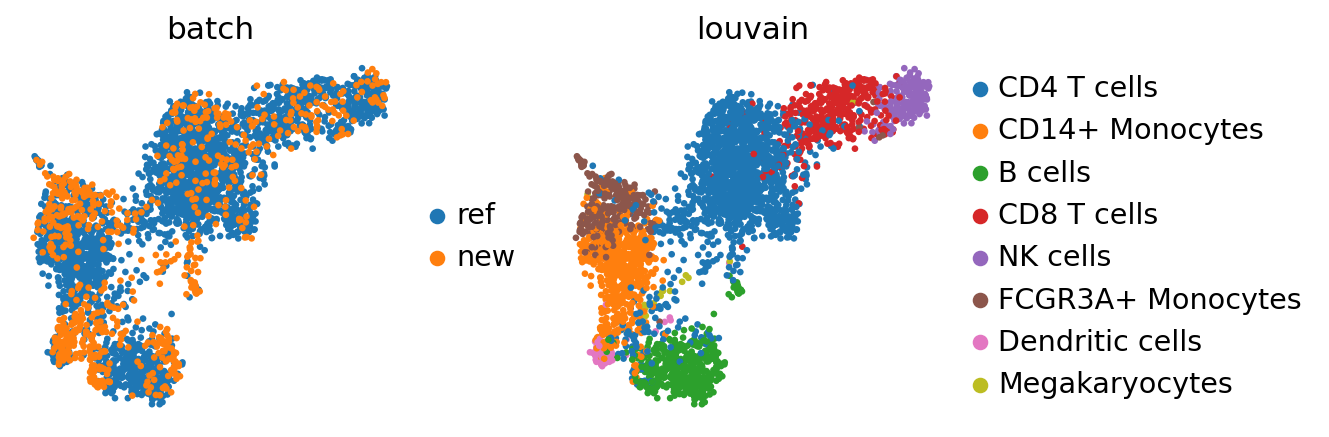

In [25]:
sc.pl.umap(adata_concat, color=["batch", "louvain"])


In [26]:
# pancreatic data human pancreas from 4 different studies [Baron et al., 2016, Muraro et al., 2016, Segerstolpe et al., 2016, Wang et al., 2016]
# note that this collection of batches is already intersected on the genes
adata_all = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)

100%|██████████| 176M/176M [00:01<00:00, 101MB/s]  
/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [27]:
adata_all.shape

(14693, 2448)

In [28]:
# inspect the cell types observed in these studies
counts = adata_all.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [ ]:
# simplify by removing 5 minority classes
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
adata_all = adata_all[~adata_all.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
adata_all.obs["celltype"] = adata_all.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())

: 

In [ ]:
# see the batch effect
sc.pp.pca(adata_all)
sc.pp.neighbors(adata_all)
sc.tl.umap(adata_all)

In [ ]:
sc.pl.umap(adata_all, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)